## 00 — Reading JSON

**JSON** (JavaScript Object Notation) is a plain-text format for storing structured data.

It is human-readable, language-agnostic, and the foundation of nearly every data format used in web mapping — including **GeoJSON**, which we cover in the next lesson.

Before we can work with spatial data, we need to be comfortable reading and navigating plain JSON.

## Allowed Data Types

JSON supports exactly **six value types**. Nothing else is valid.

| Type    | JSON example              | Python equivalent |
|---------|---------------------------|-------------------|
| string  | `"Air Force blue"`        | `str`             |
| number  | `93` or `0.36`            | `int` / `float`   |
| boolean | `true` / `false`          | `bool`            |
| null    | `null`                    | `None`            |
| object  | `{ "key": "value" }`      | `dict`            |
| array   | `[93, 138, 168]`          | `list`            |

Objects and arrays can nest inside each other to any depth.

**Common format rules:**
- Keys must be **strings in double quotes** — `"name"`, not `name` or `'name'`
- Trailing commas are **not allowed** — `[1, 2, 3,]` is invalid JSON
- Strings use `\\` to represent a single backslash

## The Example File: `latex_colors.json`

The file `data/latex_colors.json` is an **array of objects** — the top-level structure is a list `[...]`, and each element is an object describing one color.

```json
[
    {},
    {
        "name": "Air Force blue",
        "hex": "#5D8AA8",
        "latex": "\\definecolor{airforceblue}{rgb}{0.36, 0.54, 0.66}",
        "rgb": [93, 138, 168],
        "rgb2": [92, 138, 168]
    },
    ...
]
```

Things to notice:
- The **first element is an empty object** `{}` — valid JSON, but contains no data
- `"rgb"` is an **array of numbers**, not a string
- `"latex"` contains `\\` which represents a single `\` character

## Loading JSON in Python

In [3]:
import json
from pathlib import Path

path = Path("data/latex_colors.json")
colors = json.loads(path.read_text())

print(type(colors))   # <class 'list'>
print(len(colors))    # total entries including the empty one

<class 'list'>
759


## Traversal — Accessing a Single Entry

Once loaded, JSON is just Python dicts and lists. You navigate it with `[]` indexing.

In [4]:
# index 0 is the empty object — start at 1
first = colors[1]

print(first["name"])      # Air Force blue
print(first["hex"])       # #5D8AA8
print(first["rgb"])       # [93, 138, 168]
print(first["rgb"][0])    # 93  — index into the nested array

Air Force blue
#5D8AA8
[93, 138, 168]
93


## Traversal — Loop Over All Entries

In [5]:
# skip empty objects with `if not color`
for color in colors:
    if not color:
        continue
    print(color["name"], "->", color["hex"])

Air Force blue -> #5D8AA8
Alice blue -> #F0F8FF
Alizarin -> #E32636
Almond -> #EFDECD
Amaranth -> #E52B50
Amber -> #FFBF00
Amber (SAE/ECE) -> #FF7E00
American rose -> #FF033E
Amethyst -> #9966CC
Anti-flash white -> #F2F3F4
Antique brass -> #CD9575
Antique fuchsia -> #915C83
Antique white -> #FAEBD7
Ao -> #0000FF
Ao (English) -> #008000
Apple green -> #8DB600
Apricot -> #FBCEB1
Aqua -> #00FFFF
Aquamarine -> #7FFFD0
Army green -> #4B5320
Arsenic -> #3B444B
Arylide yellow -> #E9D66B
Ash grey -> #B2BEB5
Asparagus -> #87A96B
Atomic tangerine -> #FF9966
Auburn -> #6D351A
Aureolin -> #FDEE00
AuroMetalSaurus -> #6E7F80
Awesome -> #FF2052
Azure (color wheel) -> #007FFF
Azure (web) (Azure mist) -> #F0FFFF
Baby blue -> #89CFF0
Baby blue eyes -> #A1CAF1
Baby pink -> #F4C2C2
Ball Blue -> #21ABCD
Banana Mania -> #FAE7B5
Banana Yellow -> #FFE135
Battleship grey -> #848482
Bazaar -> #98777B
Beau blue -> #BCD4E6
Beaver -> #9F8170
Beige -> #F5F5DC
Bisque -> #FFE4C4
Bistre -> #3D2B1F
Bittersweet -> #FE6F

## Traversal — Look Up by Value

In [6]:
# find one entry by name
match = next((c for c in colors if c.get("name") == "Alice blue"), None)

if match:
    print(match["rgb"])   # [240, 248, 255]
else:
    print("not found")

[240, 248, 255]


## Traversal — Collect One Field Across All Entries

In [7]:
# list comprehension — collect all hex values, skipping empty entries
hex_codes = [c["hex"] for c in colors if c]

print(hex_codes[:5])

['#5D8AA8', '#F0F8FF', '#E32636', '#EFDECD', '#E52B50']


## Exercise A

Count how many color entries have a red channel (`rgb[0]`) greater than `200`. Skip empty entries.

In [2]:
import json
from pathlib import Path

path = Path("data/latex_colors.json")
colors = json.loads(path.read_text())

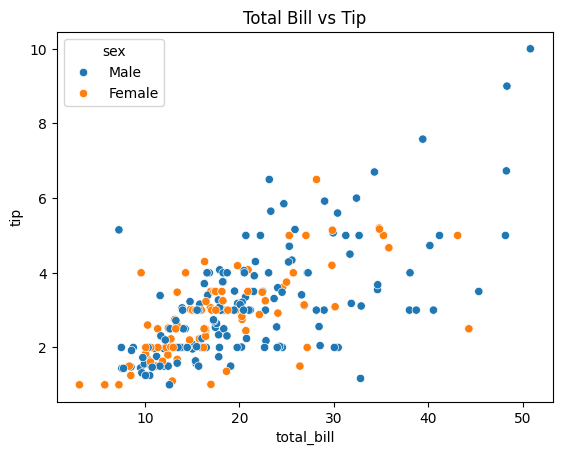

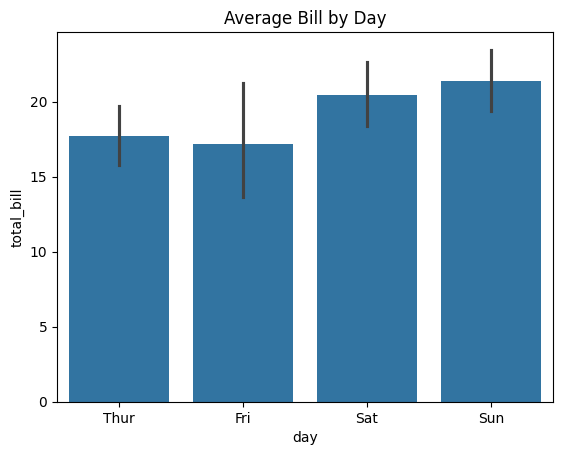

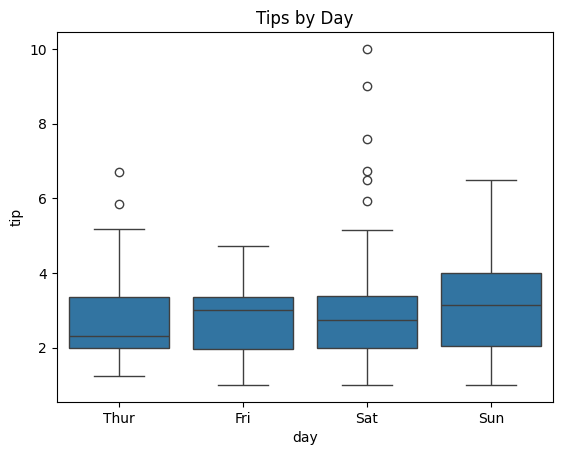

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
tips = sns.load_dataset("tips")

# Plot 1 - Trend
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")
plt.title("Total Bill vs Tip")
plt.show()

# Plot 2 - Trend
sns.barplot(data=tips, x="day", y="total_bill")
plt.title("Average Bill by Day")
plt.show()

# Plot 3 - Outliers
sns.boxplot(data=tips, x="day", y="tip")
plt.title("Tips by Day")
plt.show()

## Exercise B

Build a list of `(name, brightness)` tuples for every color, where brightness is the sum of its `rgb` values. Print the **5 brightest** colors, sorted from highest to lowest.

In [3]:
bright_colors = []

for color in colors:
    if color:
        brightness = sum(color["rgb"])
        bright_colors.append((color["name"], brightness))

bright_colors.sort(key=lambda x: x[1], reverse=True)

print(bright_colors[:5])

[('White', 765), ('Splashed white', 762), ('Snow', 755), ('Ghost white', 751), ('Azure (web) (Azure mist)', 750)]



## Check Your Understanding

The `latex_colors.json` file contains an entry for `"Alizarin"` with this `rgb` value:

```json
"rgb": [227, 38, 54]
```

Write one line of Python that prints only the **green channel** (the middle value, `38`) from that entry — starting from the loaded `colors` list.

```python
print(next(c for c in colors if c.get("name") == "Alizarin")["rgb"][1])
```


---

## Next

In [01 — GeoJSON Structure](./01-GeoJSON_Structure.ipynb), we apply these same traversal skills to a file that follows the GeoJSON convention.